
ANALYSIS 1: MEAL PERFORMANCE STATISTICS
                                 mean       std   min       50%      max
method                                                                  
Knapsack                     0.409013  0.016047  0.40  0.400000  0.45625
Knapsack (Marginal Utility)  0.572850  0.007016  0.55  0.575000  0.57500
M0 (Random)                  0.308258  0.155873  0.05  0.300000  0.62500
M1 (String Matching)         0.304367  0.127024  0.10  0.309375  0.60000
M3 (Boosted Bandit)          0.473804  0.105440  0.10  0.475000  0.60000

ANALYSIS 2: MEAL DIVERSITY & CONCENTRATION

M0 (Random) Top 5 Frequently Recommended Meals:
Cupcakes Classic (m1793)             5
Gazpacho Light (m433)                5
Chicken Fried Rice Premium (m248)    4
BBQ Chicken Special (m1736)          4
Cheese Platter Mild (m1169)          4
Name: count, dtype: int64

M1 (String Matching) Top 5 Frequently Recommended Meals:
Pasta Carbonara Special (m1996)     89
Vegetable Soup Classic (m1988)      8

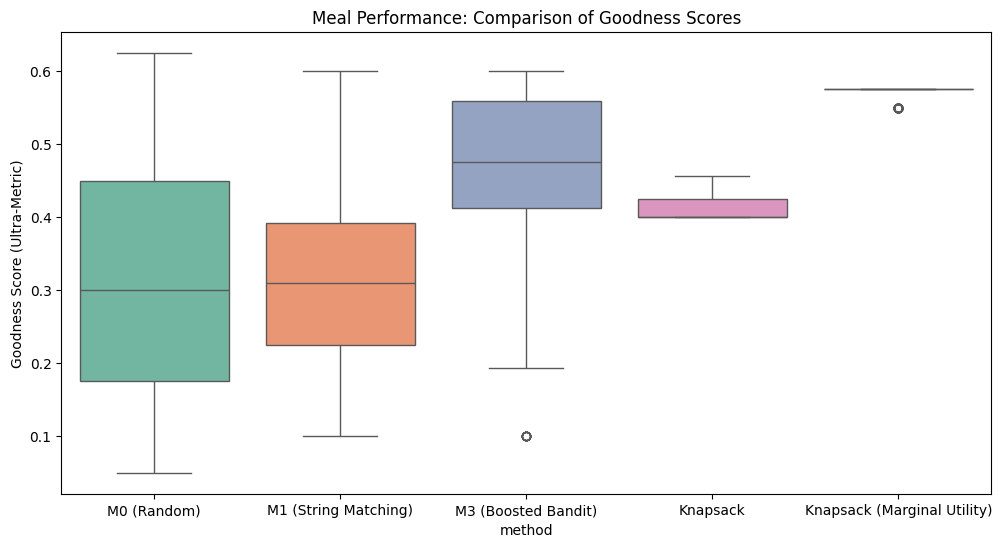

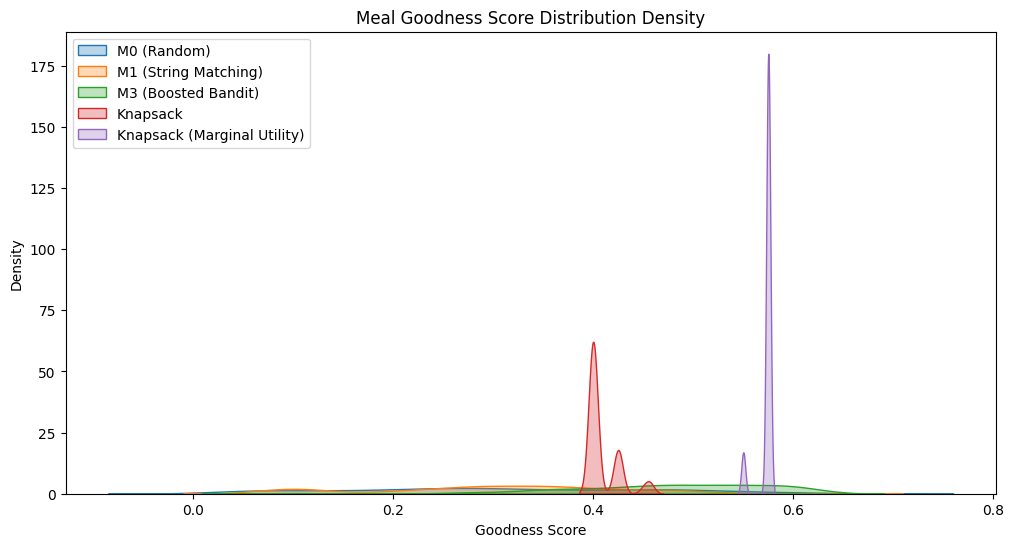

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import warnings
import glob

# Suppress specific FutureWarnings from Seaborn
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Setup Configuration
# Path where your meal result CSVs are stored
OUTPUT_DIR = "../data/meal_output_data" 

# Search for the Marginal Utility file (it often has a timestamp in the name)
m_util_search = glob.glob(os.path.join(OUTPUT_DIR, "marginal_utility_meal_results_*.csv"))
m_util_file = os.path.basename(m_util_search[0]) if m_util_search else 'marginal_utility_meal_results.csv'

# Map method names to their respective output files
file_map = {
    'M0 (Random)': 'meal_results_m0_single.csv',
    'M1 (String Matching)': 'meal_results_m1_precise.csv',
    'M3 (Boosted Bandit)': 'meal_results_m3_boosted.csv',
    'Knapsack': 'meal_results_knapsack.csv',
    'Knapsack (Marginal Utility)': 'marginal_utility_meal_results_20260210_180527.csv'
}

def load_meal_data(method_name, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    if not os.path.exists(path):
        print(f"Skipping {method_name}: File '{filename}' not found.")
        return None
    
    df = pd.read_csv(path)
    
    # Standardize column names for meals
    # Map 'team' to 'meal_bundle' and 'lead_researcher' to 'lead_meal' if they vary
    rename_map = {
        'team': 'meal_bundle',
        'lead_researcher': 'lead_meal'
    }
    df = df.rename(columns=rename_map)
    
    # Keep only essential columns for meal analysis
    cols_to_keep = ['user_id', 'meal_occasion', 'lead_meal', 'meal_bundle', 'goodness_score']
    df = df[[c for c in cols_to_keep if c in df.columns]]
    df['method'] = method_name
    
    # Convert bundle string representation back to Python list safely
    if 'meal_bundle' in df.columns:
        def safe_eval(val):
            if pd.isna(val): return []
            if isinstance(val, str):
                try:
                    return ast.literal_eval(val)
                except:
                    return []
            return val if isinstance(val, list) else []
            
        df['meal_bundle'] = df['meal_bundle'].apply(safe_eval)
        df['bundle_size'] = df['meal_bundle'].apply(len)
        
    return df

# 2. Load and Combine Data
all_dfs = [load_meal_data(name, fname) for name, fname in file_map.items()]
all_dfs = [d for d in all_dfs if d is not None]

if not all_dfs:
    print("Error: No meal result files found. Please check your file names and directory.")
else:
    comparison_df = pd.concat(all_dfs, ignore_index=True)

    # --- ANALYSIS 1: Performance Statistics ---
    print("\n" + "="*40)
    print("ANALYSIS 1: MEAL PERFORMANCE STATISTICS")
    print("="*40)
    stats = comparison_df.groupby('method')['goodness_score'].describe()
    print(stats[['mean', 'std', 'min', '50%', 'max']])
    stats.to_csv('meal_performance_stats.csv')

    # --- ANALYSIS 2: Visualization (Boxplot & Density) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=comparison_df, x='method', y='goodness_score', hue='method', palette='Set2', legend=False)
    plt.title('Meal Performance: Comparison of Goodness Scores')
    plt.ylabel('Goodness Score (Ultra-Metric)')
    plt.savefig('meal_performance_boxplot.png')
    
    plt.figure(figsize=(12, 6))
    for method in comparison_df['method'].unique():
        subset = comparison_df[comparison_df['method'] == method]
        sns.kdeplot(subset['goodness_score'], label=method, fill=True, alpha=0.3)
    plt.title('Meal Goodness Score Distribution Density')
    plt.xlabel('Goodness Score')
    plt.legend()
    plt.savefig('meal_performance_density.png')

    # --- ANALYSIS 3: Diversity & Meal Concentration ---
    print("\n" + "="*40)
    print("ANALYSIS 2: MEAL DIVERSITY & CONCENTRATION")
    print("="*40)
    
    diversity_results = []
    for method in comparison_df['method'].unique():
        m_df = comparison_df[comparison_df['method'] == method]
        
        # Flatten all meal bundles into a single list of meal names
        all_items = [meal for bundle in m_df['meal_bundle'] for meal in bundle if meal]
        meal_counts = pd.Series(all_items).value_counts()
        
        diversity_results.append({
            'Method': method,
            'Unique Meals Used': len(meal_counts),
            'Top 10 Concentration (%)': (meal_counts.head(10).sum() / meal_counts.sum() * 100) if not meal_counts.empty else 0,
            'Avg Bundle Size': m_df['bundle_size'].mean()
        })
        
        print(f"\n{method} Top 5 Frequently Recommended Meals:")
        print(meal_counts.head(5))

    diversity_df = pd.DataFrame(diversity_results)
    print("\nDiversity Summary:")
    print(diversity_df)
    diversity_df.to_csv('meal_diversity_analysis.csv', index=False)

    # --- ANALYSIS 4: Bundle Similarity (Jaccard Overlap) ---
    print("\n" + "="*40)
    print("ANALYSIS 3: MEAL BUNDLE SIMILARITY (OVERLAP)")
    print("="*40)
    
    def calculate_jaccard(list1, list2):
        if not isinstance(list1, (list, set, tuple)) or not isinstance(list2, (list, set, tuple)):
            return 0.0
        s1, s2 = set(list1), set(list2)
        if not s1 or not s2: return 0.0
        return len(s1 & s2) / len(s1 | s2) if (s1 | s2) else 0.0

    # Create a unique key for User + Occasion to pivot correctly
    comparison_df['user_occ_key'] = comparison_df['user_id'].astype(str) + '_' + comparison_df['meal_occasion'].astype(str)
    pivot_df = comparison_df.pivot(index='user_occ_key', columns='method', values='meal_bundle')
    
    # Calculate overlap between M1 and Marginal Utility as an example
    if 'M1 (String Matching)' in pivot_df.columns and 'Knapsack (Marginal Utility)' in pivot_df.columns:
        overlap = pivot_df.apply(lambda x: calculate_jaccard(x['M1 (String Matching)'], x['Knapsack (Marginal Utility)']), axis=1)
        print(f"Average Bundle Overlap (M1 vs Marginal Utility): {overlap.mean():.2%}")

    if 'M0 (Random)' in pivot_df.columns and 'Knapsack (Marginal Utility)' in pivot_df.columns:
        overlap_m0 = pivot_df.apply(lambda x: calculate_jaccard(x['M0 (Random)'], x['Knapsack (Marginal Utility)']), axis=1)
        print(f"Average Bundle Overlap (M0 vs Marginal Utility): {overlap_m0.mean():.2%}")
    
    print("\nAnalysis Complete. Files generated in the current directory.")